In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
import pandas as pd
import numpy as np
%config InlineBackend.figure_formats = ['svg']

In [1]:
!tar xvf c84a31df-c695-47c8-8e76-923b24cd0791.tar.gz

result/
result/hostname
result/aws_instance_type
result/criterion.txt
result/cpuinfo
result/free
result/tango.txt


In [3]:
def parse_criterion_mean_changes(file_name: str) -> [float]:
    result = []
    significant = []
    digit_pattern = r'[-+]?(?:[0-9]+.[0-9]+)'
    with open(file_name) as f:
        for line in f:
            line = line.replace("−", "-") # replacing strange Criterion minus sign, which is not actually minus
            matches = re.findall(f'change: \\[({digit_pattern})% ({digit_pattern})% ({digit_pattern})%\\] \\(p = ({digit_pattern}) [<=>] {digit_pattern}\\)', line)
            if matches:
                low = float(matches[0][0])
                mean = float(matches[0][1])
                high = float(matches[0][2])
                p_value = float(matches[0][3])
                result.append(mean)
                # the same criteria is used in Tango
                
                significant.append(p_value < 0.05 and min(abs(low), abs(high)) >= 0.5)
    return result, significant

def parse_tango_changes(file_name: str) -> [float]:
    result = []
    significant = []
    with open(file_name) as f:
        for line in f:
            matches = re.findall(r"([-+][0-9]+.[0-9]+)%(\*?)$", line)[0]
            result.append(float(matches[0]))
            significant.append(matches[1] == "*")
    return result, significant

In [5]:
experiment_path = "result"

tango, tango_significant = parse_tango_changes(f"{experiment_path}/tango.txt")
criterion, criterion_significant = parse_criterion_mean_changes(f"{experiment_path}/criterion.txt")
#criterion_paired, criterion_paired_significant = parse_criterion_mean_changes(f"{experiment_path}/criterion-paired.txt")

data = pd.DataFrame({
    'tango': tango,
    'criterion': criterion,
})

significant = pd.DataFrame({
    'tango': tango_significant,
    'criterion': criterion_significant,
})

display(data.describe())

,tango,criterion
count,10.000000,10.000000
mean,0.005000,2.056240
std,0.185128,2.306496
min,-0.090000,0.669800
25%,-0.080000,0.942200
50%,-0.065000,1.184500
75%,-0.002500,1.532225
max,0.520000,8.089600


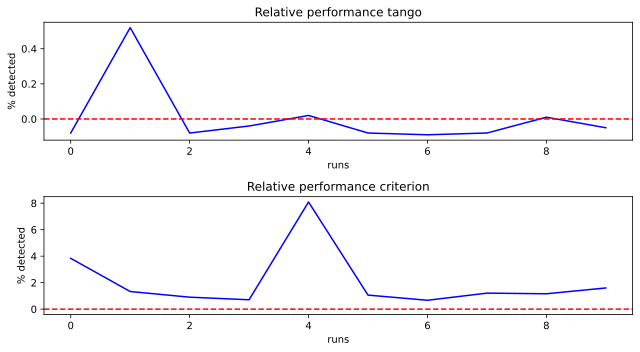

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5))

for ax, col in zip(axes, data.columns):
    ax.plot(data.index, data[col], color='blue', label="Tango")
    ax.set_title(f'Relative performance {col}')
    ax.set_xlabel('runs')
    ax.set_ylabel('% detected')
    #ax.set_yscale('symlog')

    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

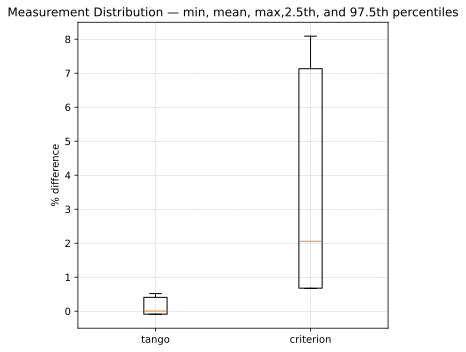

In [11]:
LOW = 0.5
HIGH = 99.5

def make_boxplot_stats(input):
    q1, q3 = np.percentile(input, [LOW, HIGH])
    return {
        'med':    np.mean(input),
        'q1':     q1,
        'q3':     q3,
        'whislo': np.min(input),
        'whishi': np.max(input),
        'fliers': []
    }

fig, ax = plt.subplots(figsize=(5, 5))

ax.bxp([make_boxplot_stats(data[col]) for col in data.columns], positions=range(1, len(data.columns) + 1), showfliers=False)

#ax.set_yscale('symlog')
#ax.set_yticks([-100, -20, -10, -1, 0, 1, 10, 20, 100])

ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_title('')
ax.set_title(f'Measurement Distribution — min, mean, max,{LOW}th, and {HIGH}th percentiles')
ax.set_ylabel('% difference')
ax.set_xticklabels(data.columns)
ax.grid(linestyle='--', linewidth=0.4)

plt.tight_layout()
plt.show()

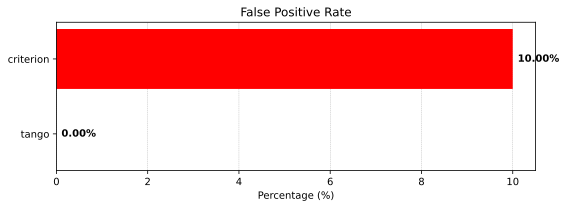

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))

bars = ax.barh(significant.columns, significant.mean() * 100, color='red')

ax.bar_label(bars, fmt='%.2f%%', padding=5, fontweight="bold")

ax.set_xlabel('Percentage (%)')
ax.set_title('False Positive Rate')

ax.grid(linestyle='--', linewidth=0.4, axis='x')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()